<a href="https://colab.research.google.com/github/proinvestigadores/Abejas/blob/main/Smart_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Carga y auditoría de datos**

## **1.1. Setup y carga de datos**

In [6]:
# ---- 0) Configuración básica de entorno
import sys, os, re, math, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Ajusta pandas para ver más columnas en prints
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

# ---- 1) Montar Google Drive y definir ruta del CSV
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Importar
folder_path = '/content/drive/MyDrive/Pigs/Smart_Manufacturing/Modelos/'
file_path = 'Bd_Procesada_Junio_2024.csv'
path = folder_path + file_path
df = pd.read_csv(path)
df.head()

Mounted at /content/drive


,Timestamp,MD1_RPM,MD2_RPM,MD3_RPM,MD4_RPM,MD5_RPM,MD1_P,MD2_P,MD3_P,MD4_P,MD5_P,MD1_APM,MD2_APM,MD3_APM,MD4_APM,MD5_APM,MD1_PORCENT,MD2_PORCENT,MD3_PORCENT,MD4_PORCENT,MD5_PORCENT,MD1_ZE_VP,MD2_ZE_VP,MD3_ZE_VP,MD4_ZE_VP,MD5_ZE_VP,MD1_FND,MD2_FND,MD3_FND,MD4_FND,MD5_FND,CBZ_Z1_SP,CBZ_Z1_VP,CBZ_Z2_SP,CBZ_Z2_VP,CBZ_Z3_SP,CBZ_Z3_VP,CBZ_Z4_SP,CBZ_Z4_VP,CBZ_Z5_SP,CBZ_Z5_VP,CBZ_Z6_SP,CBZ_Z6_VP,HAL1_VEL,HAL2_VEL,HAL3_VEL,HAL4_VEL,HAL5_VEL,HAL6_VEL
0,2024-03-19 16:30:11,20.0,3.0,3.0,3.0,10.0,4678.0,1322.0,245.0,805.0,945.0,12.100,12.495,1.7,1.7,18.380,0.88,1.32,1.32,1.39,1.23,35.8,31.5,34.9,34.0,34.2,273.1,258.1,269.6,263.9,270.4,249.0,251.4,249.0,249.0,250.0,249.7,250.0,253.6,251.0,250.8,251.0,251.0,40.4,42.2,34.0,94.5,95.3,73.0
1,2024-03-19 16:30:59,20.0,3.0,3.0,3.0,10.0,4678.0,1322.0,245.0,805.0,945.0,12.100,12.495,1.7,1.7,18.380,0.88,1.32,1.32,1.39,1.23,35.8,31.5,34.9,34.0,34.2,273.1,258.1,269.6,263.9,270.4,249.0,251.4,249.0,249.0,250.0,249.7,250.0,253.6,251.0,250.8,251.0,251.0,40.4,42.2,34.0,94.5,95.3,73.0
2,2024-03-19 16:31:58,10.0,3.0,3.0,3.0,10.0,3880.0,1250.0,225.0,795.0,928.0,11.570,12.530,1.7,1.7,18.365,0.88,1.32,1.32,1.39,1.23,35.2,31.5,34.6,34.0,34.6,273.9,255.0,271.8,264.5,269.4,249.0,251.9,249.0,249.0,250.0,249.7,250.0,253.8,251.0,250.8,251.0,250.9,40.4,42.2,34.0,94.5,95.3,73.0
3,2024-03-19 16:32:58,10.0,3.0,3.0,3.0,5.0,2928.0,1160.0,180.0,762.0,728.0,10.985,12.485,1.7,1.7,17.300,0.88,1.32,1.32,1.39,1.23,35.7,31.5,34.4,34.0,34.7,276.6,251.9,270.0,267.5,268.4,249.0,252.3,249.0,249.0,250.0,249.8,250.0,253.7,251.0,250.8,251.0,250.9,40.4,42.2,34.0,94.5,95.3,73.0
4,2024-03-19 16:33:58,10.0,3.0,3.0,3.0,5.0,2770.0,1137.0,158.0,735.0,548.0,10.960,12.420,1.7,1.7,16.125,0.88,1.32,1.32,1.39,1.23,35.8,31.4,34.4,34.0,34.2,279.4,249.0,266.8,270.5,267.5,249.0,252.4,249.0,249.2,250.0,250.0,250.0,253.4,251.0,250.8,251.0,250.9,40.4,42.2,34.0,94.5,95.3,73.0


## **1.2. Funciones de auditoría de datos**

In [7]:
# =========================================
# BLOQUE 1 — SETUP + CARGA + AUDITORÍA
# Objetivo 3: Validación del modelo (paso 1)
# =========================================

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Estandariza nombres de columnas:
    - elimina espacios al inicio/fin
    - colapsa múltiples espacios internos
    - reemplaza espacios por '_'
    - asegura ASCII simple si hubiera tildes
    """
    def fix_col(c):
        # quita espacios externos
        c = c.strip()
        # colapsa espacios intermedios
        c = re.sub(r'\s+', ' ', c)
        # reemplaza espacios por underscore
        c = c.replace(' ', '_')
        # normaliza prefijos comunes tipo 'MD1' etc. sin tocar mayúsculas útiles
        return c
    df = df.rename(columns={c: fix_col(c) for c in df.columns})
    return df


def parse_timestamp(df: pd.DataFrame, ts_col_candidates=('Timestamp','timestamp','TIMESTAMP')) -> pd.DataFrame:
    """
    Busca la columna de tiempo, la parsea a datetime y ordena por tiempo.
    """
    ts_col = None
    for c in ts_col_candidates:
        if c in df.columns:
            ts_col = c
            break
    if ts_col is None:
        raise ValueError(f"No encontré columna de tiempo. Probé {ts_col_candidates} y no existen en df.columns={df.columns.tolist()[:10]}...")

    # Parse robusto (maneja 'YYYY-MM-DD HH:MM:SS' y variantes)
    df[ts_col] = pd.to_datetime(df[ts_col], errors='coerce')
    if df[ts_col].isna().any():
        # Si hay fallos de parseo, explícitalos
        bad = df[df[ts_col].isna()]
        print("⚠️ Filas con Timestamp inválido:", len(bad))
        print(bad.head(3))
        # Puedes decidir aquí si las eliminas
        df = df.dropna(subset=[ts_col])

    df = df.sort_values(ts_col).reset_index(drop=True)
    return df, ts_col


def build_variable_families(columns):
    """
    Detecta familias de variables según prefijos/sufijos habituales del proceso:
    - RPM de módulos: MD*_RPM
    - Presiones: MD*_P (PSI)
    - % capa: MD*_PORCENT
    - Temperatura de fundido: MD*_FND
    - Temperaturas de cabezal: CBZ_Z{1..6}_SP y CBZ_Z{1..6}_VP
    - Velocidad haladores: HAL{1..6}_VEL
    Devuelve un dict con listas de columnas por familia.
    """
    fam = {
        "rpm_modulos": sorted([c for c in columns if re.fullmatch(r"MD\d+_RPM", c)]),
        "presion_modulos": sorted([c for c in columns if re.fullmatch(r"MD\d+_P", c)]),
        "porcentaje_capa": sorted([c for c in columns if re.fullmatch(r"MD\d+_PORCENT", c)]),
        "fundido_modulos": sorted([c for c in columns if re.fullmatch(r"MD\d+_FND", c)]),
        "cabezal_SP": sorted([c for c in columns if re.fullmatch(r"CBZ_Z\d+_SP", c)]),
        "cabezal_VP": sorted([c for c in columns if re.fullmatch(r"CBZ_Z\d+_VP", c)]),
        "haladores_vel": sorted([c for c in columns if re.fullmatch(r"HAL\d+_VEL", c)]),
    }
    # Extras comunes en tu BD (si existen):
    extras = sorted([c for c in columns if c not in sum(fam.values(), []) and c not in ("Timestamp","timestamp","TIMESTAMP")])
    fam["extras"] = extras
    return fam


def time_gap_audit(ts: pd.Series) -> pd.DataFrame:
    """
    Calcula deltas consecutivos y los clasifica en bins relevantes para este proceso:
     - < 30s
     - 30s–59s
     - 59s–61s (ideal ≈ 60s)
     - 61s–120s
     - 2–5 min
     - 5–10 min
     - >10 min
    Devuelve tabla con conteos y %.
    """
    # diferencias en segundos
    dt = ts.sort_values().diff().dt.total_seconds().iloc[1:]  # omite la primera (NaN)
    bins = [-np.inf, 30, 59, 61, 120, 300, 600, np.inf]
    labels = ["<30s", "30–59s", "59–61s", "61–120s", "2–5min", "5–10min", ">10min"]
    cat = pd.cut(dt, bins=bins, labels=labels)
    counts = cat.value_counts().reindex(labels, fill_value=0)
    out = pd.DataFrame({
        "rango": counts.index,
        "conteo": counts.values,
        "porcentaje": np.round(100*counts.values / counts.sum(), 2)
    })
    out.loc["TOTAL"] = ["—", int(counts.sum()), 100.00]
    return out

# Carga del CSV
assert os.path.exists(path), f"No encuentro el CSV en: {path}"
df = pd.read_csv(path)

print("Forma (filas, columnas) antes de estandarizar:", df.shape)
df = standardize_columns(df)
df, TS_COL = parse_timestamp(df)

print("Columna de tiempo detectada:", TS_COL)
print("Rango temporal:", df[TS_COL].min(), "→", df[TS_COL].max())
print("Forma (filas, columnas) tras parseo/orden:", df.shape)
print("\nPrimeras filas:")
display(df.head(5))

# Diccionario de variables por familia
familias = build_variable_families(df.columns)
print("\nResumen de familias detectadas:")
for k, v in familias.items():
    print(f" - {k}: {len(v)} columnas")
    if len(v) > 0:
        print("   ", v)

# Auditoría de gaps temporales
gap_table = time_gap_audit(df[TS_COL])
print("\n=== Auditoría de gaps entre muestras ===")
display(gap_table)

# Chequeos rápidos de calidad de datos
# a) Porcentaje de valores nulos por columna (útil para decidir interpolaciones posteriores)
nulls = df.isna().mean().sort_values(ascending=False)
print("\nTop 10 columnas con mayor % de NaN:")
display((nulls*100).round(2).head(10).to_frame("%_NaN").T)

# b) Duplicados exactos por Timestamp (según milisegundo).
#    En el proceso, lo ideal es consolidar a muestreo por minuto en un bloque posterior.
dup_count = df.duplicated(subset=[TS_COL]).sum()
print(f"\nDuplicados exactos de {TS_COL}: {dup_count}")

# c) Vista de estadísticos básicos para familias principales (sirve para detectar sensores fuera de rango):
def describe_family(cols, titulo):
    if len(cols) == 0:
        print(f"\n[{titulo}] No se encontraron columnas.")
        return
    print(f"\n[{titulo}] Estadísticos rápidos")
    display(df[cols].describe().T)

describe_family(familias["rpm_modulos"], "RPM de módulos")
describe_family(familias["presion_modulos"], "Presión de módulos (PSI)")
describe_family(familias["fundido_modulos"], "Temperatura de fundido (°C)")
describe_family(familias["cabezal_SP"], "Cabezal SP (°C)")
describe_family(familias["cabezal_VP"], "Cabezal VP (°C)")
describe_family(familias["haladores_vel"], "Velocidad haladores (m/min aprox.)")

print("\n✅ BLOQUE 1 completado. Sube estas salidas al repo para continuar con el Bloque 2.")


Forma (filas, columnas) antes de estandarizar: (20260, 49)
Columna de tiempo detectada: Timestamp
Rango temporal: 2024-03-19 16:30:11 → 2024-04-02 16:50:06
Forma (filas, columnas) tras parseo/orden: (20260, 49)

Primeras filas:


,Timestamp,MD1_RPM,MD2_RPM,MD3_RPM,MD4_RPM,MD5_RPM,MD1_P,MD2_P,MD3_P,MD4_P,MD5_P,MD1_APM,MD2_APM,MD3_APM,MD4_APM,MD5_APM,MD1_PORCENT,MD2_PORCENT,MD3_PORCENT,MD4_PORCENT,MD5_PORCENT,MD1_ZE_VP,MD2_ZE_VP,MD3_ZE_VP,MD4_ZE_VP,MD5_ZE_VP,MD1_FND,MD2_FND,MD3_FND,MD4_FND,MD5_FND,CBZ_Z1_SP,CBZ_Z1_VP,CBZ_Z2_SP,CBZ_Z2_VP,CBZ_Z3_SP,CBZ_Z3_VP,CBZ_Z4_SP,CBZ_Z4_VP,CBZ_Z5_SP,CBZ_Z5_VP,CBZ_Z6_SP,CBZ_Z6_VP,HAL1_VEL,HAL2_VEL,HAL3_VEL,HAL4_VEL,HAL5_VEL,HAL6_VEL
0,2024-03-19 16:30:11,20.0,3.0,3.0,3.0,10.0,4678.0,1322.0,245.0,805.0,945.0,12.100,12.495,1.7,1.7,18.380,0.88,1.32,1.32,1.39,1.23,35.8,31.5,34.9,34.0,34.2,273.1,258.1,269.6,263.9,270.4,249.0,251.4,249.0,249.0,250.0,249.7,250.0,253.6,251.0,250.8,251.0,251.0,40.4,42.2,34.0,94.5,95.3,73.0
1,2024-03-19 16:30:59,20.0,3.0,3.0,3.0,10.0,4678.0,1322.0,245.0,805.0,945.0,12.100,12.495,1.7,1.7,18.380,0.88,1.32,1.32,1.39,1.23,35.8,31.5,34.9,34.0,34.2,273.1,258.1,269.6,263.9,270.4,249.0,251.4,249.0,249.0,250.0,249.7,250.0,253.6,251.0,250.8,251.0,251.0,40.4,42.2,34.0,94.5,95.3,73.0
2,2024-03-19 16:31:58,10.0,3.0,3.0,3.0,10.0,3880.0,1250.0,225.0,795.0,928.0,11.570,12.530,1.7,1.7,18.365,0.88,1.32,1.32,1.39,1.23,35.2,31.5,34.6,34.0,34.6,273.9,255.0,271.8,264.5,269.4,249.0,251.9,249.0,249.0,250.0,249.7,250.0,253.8,251.0,250.8,251.0,250.9,40.4,42.2,34.0,94.5,95.3,73.0
3,2024-03-19 16:32:58,10.0,3.0,3.0,3.0,5.0,2928.0,1160.0,180.0,762.0,728.0,10.985,12.485,1.7,1.7,17.300,0.88,1.32,1.32,1.39,1.23,35.7,31.5,34.4,34.0,34.7,276.6,251.9,270.0,267.5,268.4,249.0,252.3,249.0,249.0,250.0,249.8,250.0,253.7,251.0,250.8,251.0,250.9,40.4,42.2,34.0,94.5,95.3,73.0
4,2024-03-19 16:33:58,10.0,3.0,3.0,3.0,5.0,2770.0,1137.0,158.0,735.0,548.0,10.960,12.420,1.7,1.7,16.125,0.88,1.32,1.32,1.39,1.23,35.8,31.4,34.4,34.0,34.2,279.4,249.0,266.8,270.5,267.5,249.0,252.4,249.0,249.2,250.0,250.0,250.0,253.4,251.0,250.8,251.0,250.9,40.4,42.2,34.0,94.5,95.3,73.0



Resumen de familias detectadas:
 - rpm_modulos: 5 columnas
    ['MD1_RPM', 'MD2_RPM', 'MD3_RPM', 'MD4_RPM', 'MD5_RPM']
 - presion_modulos: 5 columnas
    ['MD1_P', 'MD2_P', 'MD3_P', 'MD4_P', 'MD5_P']
 - porcentaje_capa: 5 columnas
    ['MD1_PORCENT', 'MD2_PORCENT', 'MD3_PORCENT', 'MD4_PORCENT', 'MD5_PORCENT']
 - fundido_modulos: 5 columnas
    ['MD1_FND', 'MD2_FND', 'MD3_FND', 'MD4_FND', 'MD5_FND']
 - cabezal_SP: 6 columnas
    ['CBZ_Z1_SP', 'CBZ_Z2_SP', 'CBZ_Z3_SP', 'CBZ_Z4_SP', 'CBZ_Z5_SP', 'CBZ_Z6_SP']
 - cabezal_VP: 6 columnas
    ['CBZ_Z1_VP', 'CBZ_Z2_VP', 'CBZ_Z3_VP', 'CBZ_Z4_VP', 'CBZ_Z5_VP', 'CBZ_Z6_VP']
 - haladores_vel: 6 columnas
    ['HAL1_VEL', 'HAL2_VEL', 'HAL3_VEL', 'HAL4_VEL', 'HAL5_VEL', 'HAL6_VEL']
 - extras: 10 columnas
    ['MD1_APM', 'MD1_ZE_VP', 'MD2_APM', 'MD2_ZE_VP', 'MD3_APM', 'MD3_ZE_VP', 'MD4_APM', 'MD4_ZE_VP', 'MD5_APM', 'MD5_ZE_VP']

=== Auditoría de gaps entre muestras ===


,rango,conteo,porcentaje
0,<30s,221,1.09
1,30–59s,3238,15.98
2,59–61s,14279,70.48
3,61–120s,2512,12.40
4,2–5min,9,0.04
5,5–10min,0,0.00
6,>10min,0,0.00
TOTAL,—,20259,100.00



Top 10 columnas con mayor % de NaN:


...


[Cabezal VP (°C)] Estadísticos rápidos


,count,mean,std,min,25%,50%,75%,max
CBZ_Z1_VP,20260.0,251.367270,0.766144,249.6,250.8,251.3,252.0,252.8
CBZ_Z2_VP,20260.0,248.725030,0.484118,244.6,248.3,249.0,249.0,249.9
CBZ_Z3_VP,20260.0,247.860464,0.757689,246.1,247.3,247.9,248.4,250.5
CBZ_Z4_VP,20260.0,251.406703,0.360667,250.7,251.1,251.4,251.7,253.9
CBZ_Z5_VP,20260.0,248.011841,0.251156,245.1,248.0,248.0,248.0,251.4
CBZ_Z6_VP,20260.0,248.012315,0.294222,243.8,247.9,248.0,248.1,252.5



[Velocidad haladores (m/min aprox.)] Estadísticos rápidos


,count,mean,std,min,25%,50%,75%,max
HAL1_VEL,20260.0,40.004980,1.046879,35.2,39.8,40.1,40.8,41.1
HAL2_VEL,20260.0,41.762665,1.092682,36.5,41.6,41.9,42.5,42.7
HAL3_VEL,20260.0,34.000000,0.000000,34.0,34.0,34.0,34.0,34.0
HAL4_VEL,20260.0,89.457295,2.645648,77.4,89.1,89.7,91.0,94.5
HAL5_VEL,20260.0,94.284970,2.450095,83.2,94.0,94.1,96.0,97.0
HAL6_VEL,20260.0,73.277853,1.930675,64.5,73.0,73.5,74.7,75.2



✅ BLOQUE 1 completado. Sube estas salidas al repo para continuar con el Bloque 2.


# **2. Filtro de outliers y etiquetado de estados**

## **2.1. Normalización temporal + filtro de outliers**

In [8]:
from IPython.display import display

# --- Validaciones mínimas ---
if 'df' not in globals() or 'TS_COL' not in globals():
    raise RuntimeError("No encuentro 'df' o 'TS_COL'. Ejecutar antes el Bloque 1.")

# --- Utilidades (definidas aquí para evitar dependencias del orden de celdas) ---
def build_variable_families(columns):
    import re
    fam = {
        "rpm_modulos": sorted([c for c in columns if re.fullmatch(r"MD\d+_RPM", c)]),
        "presion_modulos": sorted([c for c in columns if re.fullmatch(r"MD\d+_P", c)]),
        "porcentaje_capa": sorted([c for c in columns if re.fullmatch(r"MD\d+_PORCENT", c)]),
        "fundido_modulos": sorted([c for c in columns if re.fullmatch(r"MD\d+_FND", c)]),
        "cabezal_SP": sorted([c for c in columns if re.fullmatch(r"CBZ_Z\d+_SP", c)]),
        "cabezal_VP": sorted([c for c in columns if re.fullmatch(r"CBZ_Z\d+_VP", c)]),
        "haladores_vel": sorted([c for c in columns if re.fullmatch(r"HAL\d+_VEL", c)]),
    }
    extras = sorted([c for c in columns if c not in sum(fam.values(), []) and c not in (TS_COL,)])
    fam["extras"] = extras
    return fam

def cap_outliers_df(df_num: pd.DataFrame, iqr_k: float = 3.0, p_low: float = 0.001, p_high: float = 0.999):
    """
    Aplica capping columna a columna usando dos criterios:
    - Regla de Tukey extendida: [Q1 - k*IQR, Q3 + k*IQR]
    - Percentiles (p_low, p_high) para robustecer límites
    Devuelve (df_capped, reporte_df) sin modificar el df de entrada.
    """
    capped = df_num.copy()
    rows = []
    for col in df_num.columns:
        s = df_num[col]
        if not np.issubdtype(s.dtype, np.number):
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if np.isfinite(iqr) and iqr > 0:
            low_iqr = q1 - iqr_k * iqr
            high_iqr = q3 + iqr_k * iqr
        else:
            # Si la columna es casi constante, usa solo percentiles
            low_iqr = s.min()
            high_iqr = s.max()
        low_p = s.quantile(p_low)
        high_p = s.quantile(p_high)
        low_cap = max(low_iqr, low_p)
        high_cap = min(high_iqr, high_p)

        s_clipped = s.clip(lower=low_cap, upper=high_cap)
        changed = (s_clipped != s) & s.notna()
        capped[col] = s_clipped

        rows.append({
            "columna": col,
            "n_total": int(s.notna().sum()),
            "capados": int(changed.sum()),
            "min_original": float(np.nanmin(s)),
            "p001": float(low_p),
            "Q1": float(q1),
            "Q3": float(q3),
            "p999": float(high_p),
            "max_original": float(np.nanmax(s)),
            "min_nuevo": float(np.nanmin(s_clipped)),
            "max_nuevo": float(np.nanmax(s_clipped))
        })
    report = pd.DataFrame(rows).sort_values("capados", ascending=False).reset_index(drop=True)
    return capped, report

# --- 1) Copia de trabajo y resampleo a 1 min ---
dfw = df.copy()
# Asegurar orden temporal por si acaso
dfw = dfw.sort_values(TS_COL).reset_index(drop=True)

# Selecciona solo numéricas para operaciones de promedio/interpolación
num_cols = dfw.select_dtypes(include='number').columns.tolist()

# Index temporal (DatetimeIndex) para resample; no se modifica df original
df_num = dfw.set_index(TS_COL)[num_cols]

# Resampleo a 1 min con promedio; mantiene únicamente columnas numéricas
df_num_1min = df_num.resample('1min').mean()

# Interpolación temporal (hasta 2 minutos seguidos de NaN).
# 'limit_direction="both"' rellena huecos al inicio/fin hasta el límite.
df_num_1min = df_num_1min.interpolate(method='time', limit=2, limit_direction='both')

print("Forma numérica tras resampleo a 1min:", df_num_1min.shape)

# --- 2) Capping de outliers (incluye el caso MD4_ZE_VP si existe) ---
df_capped, capping_report = cap_outliers_df(df_num_1min, iqr_k=3.0, p_low=0.001, p_high=0.999)

print("\n=== Bitácora de capping (top 10 por cantidad de valores capados) ===")
display(capping_report.head(10))

if "MD4_ZE_VP" in df_capped.columns:
    fila = capping_report[capping_report["columna"] == "MD4_ZE_VP"]
    if not fila.empty:
        print("\nResumen específico de MD4_ZE_VP:")
        display(fila)

# --- 3) Reconstrucción de df_1min (numérico limpio) y reporte rápido ---
df_1min = df_capped.copy()
df_1min.index.name = TS_COL  # etiqueta el índice para consistencia

print("\nEstadísticos rápidos post-capping (MD*_ZE_VP si existe):")
ze_cols = [c for c in df_1min.columns if c.endswith("_ZE_VP")]
if ze_cols:
    display(df_1min[ze_cols].describe().T)

# --- 4) Familias sobre el nuevo df_1min (para siguientes bloques) ---
familias_1min = build_variable_families(df_1min.columns)
print("\nFamilias detectadas en df_1min (numéricas):")
for k, v in familias_1min.items():
    if k != "extras":
        print(f" - {k}: {len(v)}")
print("Extras:", len(familias_1min["extras"]))

print("\n✅ BLOQUE 2A completado. Usar 'df_1min' para ingeniería de características y reglas de estado.")


Forma numérica tras resampleo a 1min: (20181, 48)

=== Bitácora de capping (top 10 por cantidad de valores capados) ===


,columna,n_total,capados,min_original,p001,Q1,Q3,p999,max_original,min_nuevo,max_nuevo
0,MD4_ZE_VP,20181,2295,33.7,33.80,33.90,34.00,106.194,6550.30,33.80,34.30
1,HAL4_VEL,20181,742,77.4,77.40,89.10,91.00,94.500,94.50,83.40,94.50
2,MD5_APM,20181,655,0.0,0.00,24.14,25.37,27.450,27.83,20.45,27.45
3,MD4_P,20181,564,60.0,70.63,3030.00,3550.00,4180.000,4500.00,1470.00,4180.00
4,MD2_P,20181,563,107.0,137.00,4244.00,5008.00,5650.280,6151.00,1952.00,5650.28
5,MD4_RPM,20181,543,0.0,0.00,27.00,33.00,41.000,42.00,9.00,41.00
6,MD4_APM,20181,542,0.0,0.00,15.90,19.40,24.100,24.70,5.40,24.10
7,MD2_RPM,20181,541,0.0,0.00,27.00,34.00,41.000,41.00,6.00,41.00
8,HAL5_VEL,20181,536,83.2,83.20,94.00,96.00,97.000,97.00,88.00,97.00
9,HAL2_VEL,20181,536,36.5,36.50,41.60,42.50,42.700,42.70,38.90,42.70



Resumen específico de MD4_ZE_VP:


,columna,n_total,capados,min_original,p001,Q1,Q3,p999,max_original,min_nuevo,max_nuevo
0,MD4_ZE_VP,20181,2295,33.7,33.8,33.9,34.0,106.194,6550.3,33.8,34.3



Estadísticos rápidos post-capping (MD*_ZE_VP si existe):


,count,mean,std,min,25%,50%,75%,max
MD1_ZE_VP,20181.0,35.627207,0.365160,35.00,35.3,35.600,35.900,37.364
MD2_ZE_VP,20181.0,31.957521,0.927722,29.65,31.3,31.750,32.800,36.582
MD3_ZE_VP,20181.0,34.758208,0.207461,34.30,34.6,34.775,34.900,35.800
MD4_ZE_VP,20181.0,34.002401,0.119312,33.80,33.9,34.000,34.000,34.300
MD5_ZE_VP,20181.0,34.515702,0.295526,34.00,34.3,34.500,34.725,35.382



Familias detectadas en df_1min (numéricas):
 - rpm_modulos: 5
 - presion_modulos: 5
 - porcentaje_capa: 5
 - fundido_modulos: 5
 - cabezal_SP: 6
 - cabezal_VP: 6
 - haladores_vel: 6
Extras: 10

✅ BLOQUE 2A completado. Usar 'df_1min' para ingeniería de características y reglas de estado.


## **2.2. Ventanas y reglas de estado**

1.   Este bloque parte desde *df_1min* (datetimelike a 1 min) y *familias_1min*.
2.   Construye _features_ por ventana de 5 minutos con métricas: nivel y variabilidad temporal de haladores, RPM, presión y desviación de cabezal.
3. Aprende umbrales automáticos a partir de cuantiles para distinguir: PARO, PRODUCCION, SETUP, DESPERDICIO.
4. Genera una línea de tiempo de estados y un reporte de conteos/porcentajes, más un diccionario con los umbrales utilizados (todo exportable a CSV/JSON).

=== Familias detectadas (para construir ventanas) ===
- Haladores (HAL*_VEL): 6 columnas
- RPM módulos (MD*_RPM): 5 columnas
- Presión módulos (MD*_P): 5 columnas
- Cabezal SP (CBZ_Z*_SP): 6 columnas
- Cabezal VP (CBZ_Z*_VP): 6 columnas

=== Rango temporal en df_1min ===
2024-03-19 16:30:00 → 2024-04-02 16:50:00
Total de filas (minutos): 20181

Ventana de visualización sugerida: 2024-03-19 16:30:00 → 2024-03-20 00:30:00 (~8 h)
(Edita PLOT_HOURS si quieres ver un tramo mayor.)


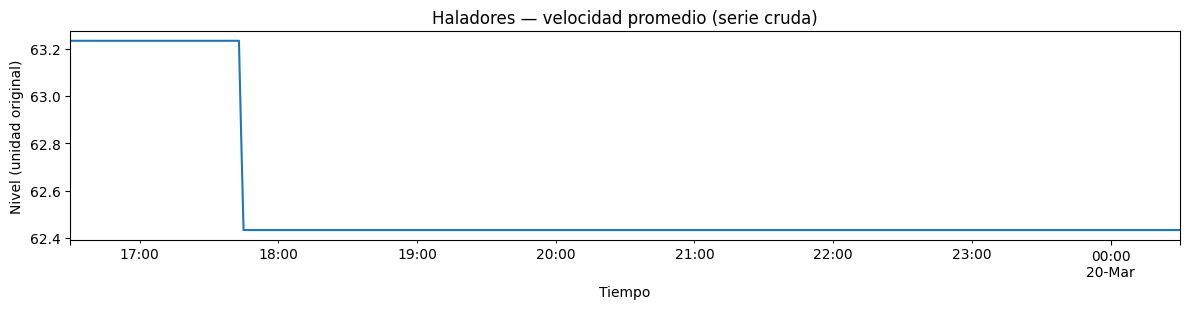

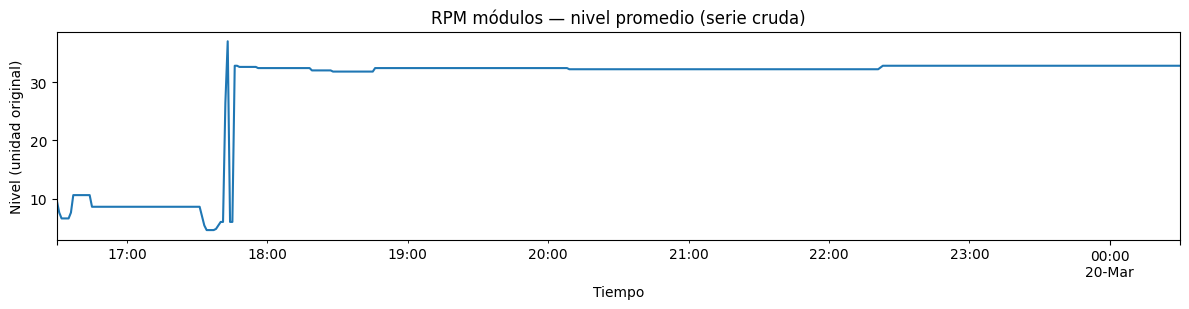

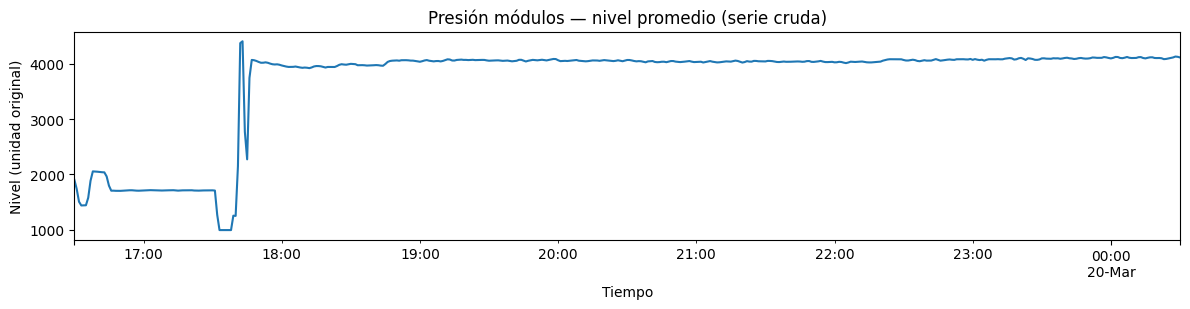

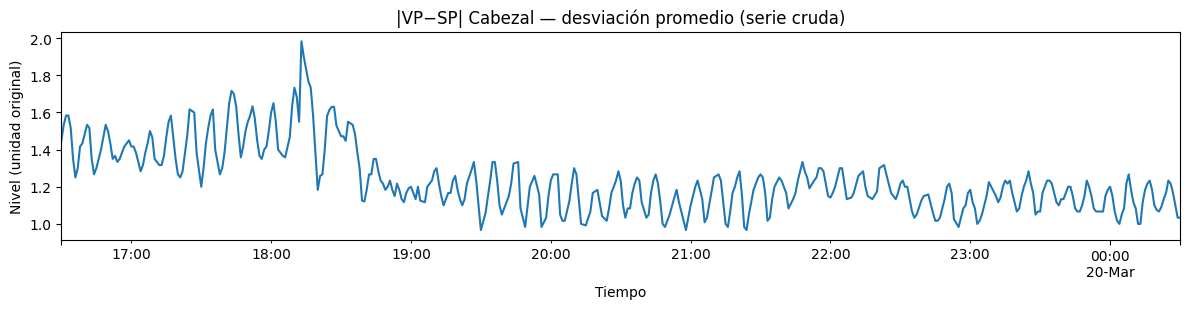


=== Vista de características (primeras 10 filas) ===


,hal_speed_mean_5m,hal_speed_std_5m,hal_pct_zero_5m,rpm_level_mean_5m,rpm_var_t_5m,rpm_absdiff_5m,pres_level_mean_5m,pres_var_t_5m,cbz_dev_mean_5m,cbz_dev_std_5m
Timestamp,,,,,,,,,,
2024-03-19 16:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-19 16:31:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-19 16:32:00,63.233333,0.0,0.0,7.933333,1.527525,NaN,1715.533333,197.659944,1.522222,0.067358
2024-03-19 16:33:00,63.233333,0.0,0.0,7.600000,1.414214,1.00,1646.650000,212.193206,1.537500,0.062915
2024-03-19 16:34:00,63.233333,0.0,0.0,7.400000,1.303840,0.75,1605.600000,205.414167,1.533333,0.055277
2024-03-19 16:35:00,63.233333,0.0,0.0,6.800000,0.447214,0.60,1514.080000,128.401760,1.513333,0.096032
2024-03-19 16:36:00,63.233333,0.0,0.0,6.800000,0.447214,0.40,1482.320000,61.247465,1.456667,0.149815
2024-03-19 16:37:00,63.233333,0.0,0.0,7.600000,1.732051,0.80,1557.840000,192.459003,1.400000,0.143372
2024-03-19 16:38:00,63.233333,0.0,0.0,8.400000,2.049390,0.80,1680.920000,276.630678,1.366667,0.104083



=== Umbrales utilizados (tabla) ===


,speed_active_thresh,speed_paro_thresh,rpm_var_lo_p25,rpm_var_hi_p75,hal_var_lo_p25,hal_var_hi_p75,cbz_dev_mid_p50,cbz_dev_hi_p75,pres_high_thresh,pct_zero_hi
0,60.383333,30.191667,0.0,0.0,0.0,0.0,1.143333,1.216667,3704.88,0.8


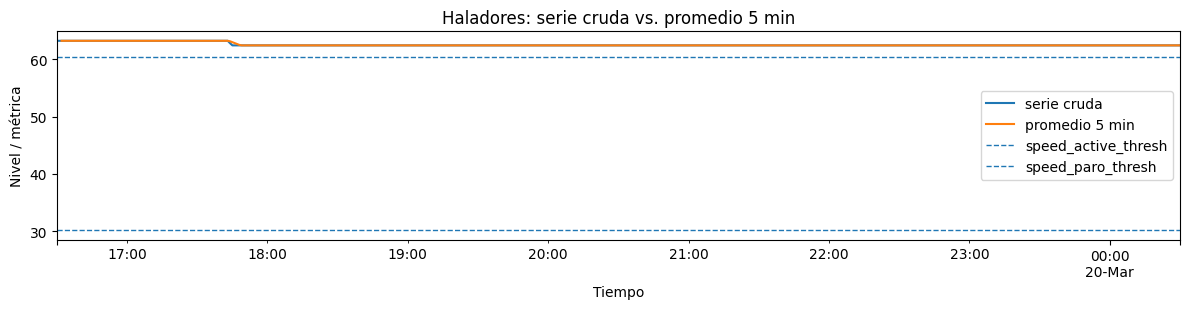

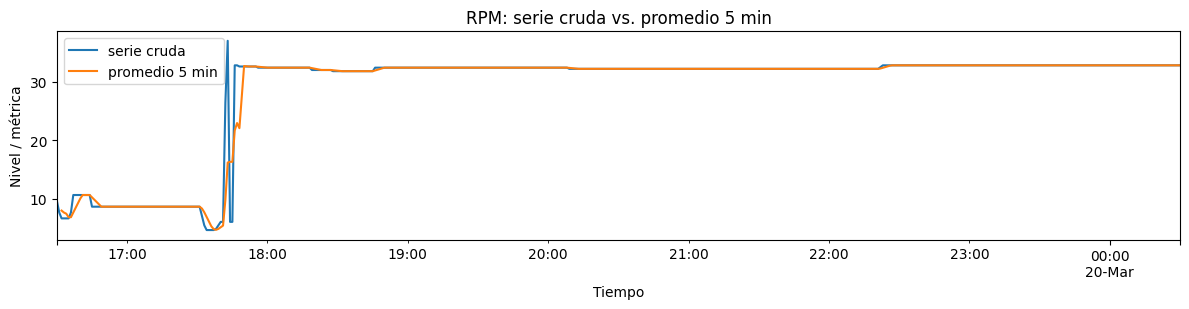

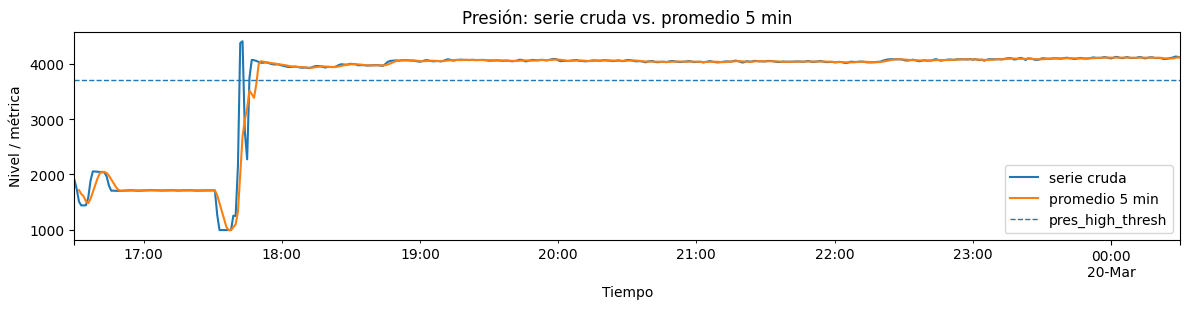

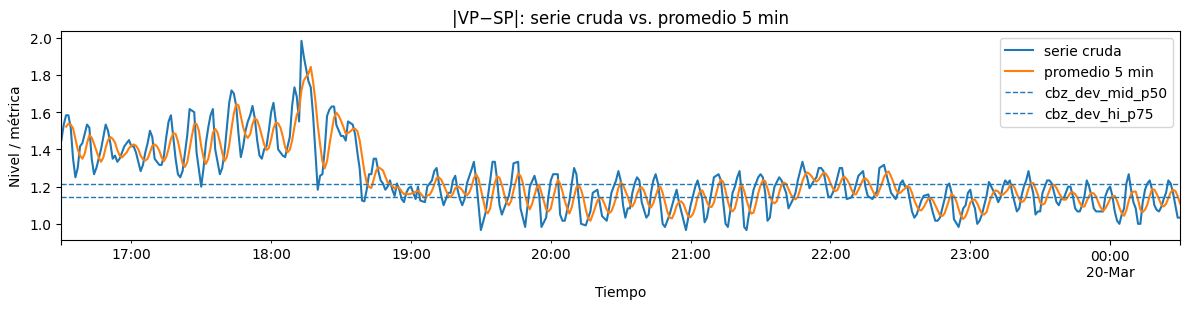


=== Conteo de flags por regla (antes de resolver solapamientos) ===


,conteo
is_paro,0
is_produccion,8716
is_desperdicio,3637



=== Timeline (muestra en la ventana de visualización) ===


,hal_speed_mean_5m,hal_speed_std_5m,hal_pct_zero_5m,rpm_level_mean_5m,rpm_var_t_5m,rpm_absdiff_5m,pres_level_mean_5m,pres_var_t_5m,cbz_dev_mean_5m,cbz_dev_std_5m,estado
Timestamp,,,,,,,,,,,
2024-03-19 16:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SETUP
2024-03-19 16:31:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SETUP
2024-03-19 16:32:00,63.233333,0.0,0.0,7.933333,1.527525,NaN,1715.533333,197.659944,1.522222,0.067358,SETUP
2024-03-19 16:33:00,63.233333,0.0,0.0,7.600000,1.414214,1.00,1646.650000,212.193206,1.537500,0.062915,SETUP
2024-03-19 16:34:00,63.233333,0.0,0.0,7.400000,1.303840,0.75,1605.600000,205.414167,1.533333,0.055277,SETUP
2024-03-19 16:35:00,63.233333,0.0,0.0,6.800000,0.447214,0.60,1514.080000,128.401760,1.513333,0.096032,SETUP
2024-03-19 16:36:00,63.233333,0.0,0.0,6.800000,0.447214,0.40,1482.320000,61.247465,1.456667,0.149815,SETUP
2024-03-19 16:37:00,63.233333,0.0,0.0,7.600000,1.732051,0.80,1557.840000,192.459003,1.400000,0.143372,SETUP
2024-03-19 16:38:00,63.233333,0.0,0.0,8.400000,2.049390,0.80,1680.920000,276.630678,1.366667,0.104083,SETUP



=== Distribución final de estados ===


,conteo,porcentaje
estado,,
PRODUCCION,8716,43.19
SETUP,7828,38.79
DESPERDICIO,3637,18.02



=== Matriz de transiciones (estado anterior → estado actual) ===


actual,DESPERDICIO,PRODUCCION,SETUP
anterior,,,
DESPERDICIO,3006,619,12
INICIO,0,0,1
PRODUCCION,615,7384,716
SETUP,16,713,7099



✅ BLOQUE completado.


In [11]:
# =========================================
# # Requisitos: df_1min (index temporal a 1 min), familias_1min y TS_COL (de Bloques 1 y 2A)
# =========================================
import matplotlib.pyplot as plt
from IPython.display import display

# ---------- 0) Validaciones de entorno ----------
if 'df_1min' not in globals():
    raise RuntimeError("No encuentro 'df_1min'. Ejecuta antes el Bloque 2A.")
if 'familias_1min' not in globals():
    raise RuntimeError("No encuentro 'familias_1min'. Ejecuta antes el Bloque 2A.")
if 'TS_COL' not in globals():
    raise RuntimeError("No encuentro 'TS_COL'. Ejecuta antes el Bloque 1.")

# ---------- 1) Familias de variables y series “crudas” clave ----------
HAL = familias_1min.get("haladores_vel", [])
RPM = familias_1min.get("rpm_modulos", [])
PRES = familias_1min.get("presion_modulos", [])
CBZ_SP = familias_1min.get("cabezal_SP", [])
CBZ_VP = familias_1min.get("cabezal_VP", [])

print("=== Familias detectadas (para construir ventanas) ===")
print(f"- Haladores (HAL*_VEL): {len(HAL)} columnas")
print(f"- RPM módulos (MD*_RPM): {len(RPM)} columnas")
print(f"- Presión módulos (MD*_P): {len(PRES)} columnas")
print(f"- Cabezal SP (CBZ_Z*_SP): {len(CBZ_SP)} columnas")
print(f"- Cabezal VP (CBZ_Z*_VP): {len(CBZ_VP)} columnas")

if not HAL:
    raise RuntimeError("No hay columnas de haladores (HAL*_VEL). Son necesarias para el etiquetado de estados.")

# Series crudas base (nivel por minuto)
def _safe_mean(df: pd.DataFrame, cols: list) -> pd.Series:
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.Series(index=df.index, dtype='float64')
    return df[cols].mean(axis=1)

hal_speed = _safe_mean(df_1min, HAL)                       # avance de línea
rpm_level = _safe_mean(df_1min, RPM) if RPM else pd.Series(index=df_1min.index, dtype='float64')
pres_level = _safe_mean(df_1min, PRES) if PRES else pd.Series(index=df_1min.index, dtype='float64')

# |VP - SP| promedio entre zonas del cabezal
if CBZ_SP and CBZ_VP:
    zones = []
    for sp in CBZ_SP:
        vp = sp.replace("_SP", "_VP")
        if vp in df_1min.columns:
            zones.append((vp, sp))
    if zones:
        cbz_dev = pd.concat([(df_1min[vp] - df_1min[sp]).abs() for (vp, sp) in zones], axis=1).mean(axis=1)
    else:
        cbz_dev = pd.Series(index=df_1min.index, dtype='float64')
else:
    cbz_dev = pd.Series(index=df_1min.index, dtype='float64')

# Rango temporal de trabajo
print("\n=== Rango temporal en df_1min ===")
print(df_1min.index.min(), "→", df_1min.index.max())
print(f"Total de filas (minutos): {len(df_1min)}")

# ---------- 2) Selección de una ventana de visualización (para gráficas) ----------
# Para no saturar, graficamos por defecto ~8 horas continuas desde el inicio.
PLOT_HOURS = 8
start_ts = df_1min.index.min()
end_ts = start_ts + pd.Timedelta(hours=PLOT_HOURS)
if end_ts > df_1min.index.max():
    end_ts = df_1min.index.max()
plot_slice = slice(start_ts, end_ts)
print(f"\nVentana de visualización sugerida: {start_ts} → {end_ts} (~{PLOT_HOURS} h)\n"
      f"(Edita PLOT_HOURS si quieres ver un tramo mayor.)")

# ---------- 3) Gráficas de series crudas (nivel) ----------
# Nota: se usa Matplotlib simple y una figura por gráfico (evita warnings/deprecaciones).
def _quick_plot(series: pd.Series, title: str):
    plt.figure(figsize=(12, 3.2))
    series.loc[plot_slice].plot()
    plt.title(title)
    plt.xlabel("Tiempo")
    plt.ylabel("Nivel (unidad original)")
    plt.tight_layout()
    plt.show()

_quick_plot(hal_speed, "Haladores — velocidad promedio (serie cruda)")
if not rpm_level.empty:
    _quick_plot(rpm_level, "RPM módulos — nivel promedio (serie cruda)")
if not pres_level.empty:
    _quick_plot(pres_level, "Presión módulos — nivel promedio (serie cruda)")
if not cbz_dev.empty:
    _quick_plot(cbz_dev, "|VP−SP| Cabezal — desviación promedio (serie cruda)")

# ---------- 4) Construcción de características en ventanas (5 min, paso 1 min) ----------
# Una "ventana" de 5 minutos suaviza y resume el comportamiento reciente para cada instante.
WINDOW = '5min'
MINP = 3  # se requieren al menos 3 datos dentro de la ventana

def _roll_mean(s): return s.rolling(window=WINDOW, min_periods=MINP).mean()
def _roll_std(s):  return s.rolling(window=WINDOW, min_periods=MINP).std()

# Variabilidad temporal agregada: |Δ| minuto a minuto promedio entre columnas
def _rolling_mean_absdiff(df: pd.DataFrame, cols: list) -> pd.Series:
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.Series(index=df.index, dtype='float64')
    absdiff = df[cols].diff().abs().mean(axis=1)
    return absdiff.rolling(window=WINDOW, min_periods=MINP).mean()

def _percent_zero_haladores(df: pd.DataFrame, hal_cols: list) -> pd.Series:
    hal_cols = [c for c in hal_cols if c in df.columns]
    zeros = df[hal_cols].eq(0).astype('float64')
    z_time = zeros.rolling(window=WINDOW, min_periods=MINP).mean()
    return z_time.mean(axis=1)  # promedio entre haladores

features = pd.DataFrame(index=df_1min.index)
features["hal_speed_mean_5m"] = _roll_mean(hal_speed)
features["hal_speed_std_5m"]  = _roll_std(hal_speed)
features["hal_pct_zero_5m"]   = _percent_zero_haladores(df_1min, HAL)

if not rpm_level.empty:
    features["rpm_level_mean_5m"] = _roll_mean(rpm_level)
    features["rpm_var_t_5m"]      = _roll_std(rpm_level)
    features["rpm_absdiff_5m"]    = _rolling_mean_absdiff(df_1min, RPM)

if not pres_level.empty:
    features["pres_level_mean_5m"] = _roll_mean(pres_level)
    features["pres_var_t_5m"]      = _roll_std(pres_level)

if not cbz_dev.empty:
    features["cbz_dev_mean_5m"] = _roll_mean(cbz_dev)
    features["cbz_dev_std_5m"]  = _roll_std(cbz_dev)

print("\n=== Vista de características (primeras 10 filas) ===")
display(features.head(10))

# ---------- 5) Umbrales automáticos (explicados) ----------
def _robust_q(s: pd.Series, q: float, fallback=np.nan):
    try:
        v = s.quantile(q)
        if pd.isna(v): return fallback
        return float(v)
    except Exception:
        return fallback

pos_hal = hal_speed[hal_speed > 0]
speed_active_thresh = _robust_q(pos_hal, 0.10, fallback=0.0)   # p10 de haladores > 0 → "línea activa"
speed_paro_thresh   = 0.5 * speed_active_thresh                # 50% de lo activo → "paro contundente"

rpm_var_hi = _robust_q(features["rpm_var_t_5m"].dropna(), 0.75, fallback=np.nan) if "rpm_var_t_5m" in features else np.nan
rpm_var_lo = _robust_q(features["rpm_var_t_5m"].dropna(), 0.25, fallback=np.nan) if "rpm_var_t_5m" in features else np.nan
hal_var_hi = _robust_q(features["hal_speed_std_5m"].dropna(), 0.75, fallback=np.nan)
hal_var_lo = _robust_q(features["hal_speed_std_5m"].dropna(), 0.25, fallback=np.nan)
dev_hi     = _robust_q(features["cbz_dev_mean_5m"].dropna(), 0.75, fallback=np.nan) if "cbz_dev_mean_5m" in features else np.nan
dev_mid    = _robust_q(features["cbz_dev_mean_5m"].dropna(), 0.50, fallback=np.nan) if "cbz_dev_mean_5m" in features else np.nan

if "pres_level_mean_5m" in features:
    pres_med     = _robust_q(features["pres_level_mean_5m"].dropna(), 0.50, fallback=np.nan)
    pres_high_th = np.nanmax([300.0, pres_med])
else:
    pres_high_th = np.nan

pct_zero_hi = 0.8  # 80% de ceros dentro de la ventana

thresholds_df = pd.DataFrame.from_dict({
    "speed_active_thresh": [speed_active_thresh],
    "speed_paro_thresh":   [speed_paro_thresh],
    "rpm_var_lo_p25":      [rpm_var_lo],
    "rpm_var_hi_p75":      [rpm_var_hi],
    "hal_var_lo_p25":      [hal_var_lo],
    "hal_var_hi_p75":      [hal_var_hi],
    "cbz_dev_mid_p50":     [dev_mid],
    "cbz_dev_hi_p75":      [dev_hi],
    "pres_high_thresh":    [pres_high_th],
    "pct_zero_hi":         [pct_zero_hi],
})
print("\n=== Umbrales utilizados (tabla) ===")
display(thresholds_df)

# ---------- 6) Gráficas intermedias con ventanas y umbrales ----------
def _plot_with_window_and_lines(raw_series, win_series, title, hlines: dict):
    plt.figure(figsize=(12, 3.2))
    raw_series.loc[plot_slice].plot(label="serie cruda")
    if win_series is not None:
        win_series.loc[plot_slice].plot(label="promedio 5 min")
    for name, y in (hlines or {}).items():
        if pd.notna(y):
            plt.axhline(y, linestyle="--", linewidth=1.0, label=name)
    plt.title(title)
    plt.xlabel("Tiempo"); plt.ylabel("Nivel / métrica")
    plt.legend()
    plt.tight_layout()
    plt.show()

_plot_with_window_and_lines(
    hal_speed, features["hal_speed_mean_5m"],
    "Haladores: serie cruda vs. promedio 5 min",
    {"speed_active_thresh": speed_active_thresh, "speed_paro_thresh": speed_paro_thresh}
)

if "rpm_level_mean_5m" in features:
    _plot_with_window_and_lines(
        rpm_level, features["rpm_level_mean_5m"],
        "RPM: serie cruda vs. promedio 5 min",
        {}
    )
if "pres_level_mean_5m" in features:
    _plot_with_window_and_lines(
        pres_level, features["pres_level_mean_5m"],
        "Presión: serie cruda vs. promedio 5 min",
        {"pres_high_thresh": pres_high_th}
    )
if "cbz_dev_mean_5m" in features:
    _plot_with_window_and_lines(
        cbz_dev, features["cbz_dev_mean_5m"],
        "|VP−SP|: serie cruda vs. promedio 5 min",
        {"cbz_dev_mid_p50": dev_mid, "cbz_dev_hi_p75": dev_hi}
    )

# ---------- 7) Reglas de estado (paso a paso) ----------
is_paro = (
    (features["hal_speed_mean_5m"] <= speed_paro_thresh) |
    (features["hal_pct_zero_5m"]   >= pct_zero_hi)
)

is_produccion = (
    (features["hal_speed_mean_5m"] >= speed_active_thresh) &
    ((pd.isna(rpm_var_lo) | (features.get("rpm_var_t_5m", pd.Series(index=features.index)) <= rpm_var_lo)) &
     (pd.isna(hal_var_lo) | (features["hal_speed_std_5m"] <= hal_var_lo)) &
     (pd.isna(dev_mid)    | (features.get("cbz_dev_mean_5m", pd.Series(index=features.index)) <= dev_mid))) &
    (pd.isna(pres_high_th) | (features.get("pres_level_mean_5m", pd.Series(index=features.index)) >= 0))
) & (~is_paro)

is_desperdicio = (
    (features["hal_speed_mean_5m"] >= speed_active_thresh) &
    (
        ((not pd.isna(rpm_var_hi)) & (features.get("rpm_var_t_5m", pd.Series(index=features.index)) >= rpm_var_hi)) |
        ((not pd.isna(hal_var_hi)) & (features["hal_speed_std_5m"] >= hal_var_hi)) |
        ((not pd.isna(dev_hi))     & (features.get("cbz_dev_mean_5m", pd.Series(index=features.index)) >= dev_hi))
    ) &
    (pd.isna(pres_high_th) | (features.get("pres_level_mean_5m", pd.Series(index=features.index)) >= pres_high_th))
) & (~is_paro) & (~is_produccion)

labels = pd.Series(index=features.index, dtype='object')
labels.loc[is_paro]       = "PARO"
labels.loc[is_produccion] = "PRODUCCION"
labels.loc[is_desperdicio]= "DESPERDICIO"
labels.fillna("SETUP", inplace=True)

# Conteo de flags (antes de resolución final)
flags_report = pd.DataFrame({
    "is_paro": is_paro.sum(),
    "is_produccion": is_produccion.sum(),
    "is_desperdicio": is_desperdicio.sum()
}, index=["conteo"]).T
print("\n=== Conteo de flags por regla (antes de resolver solapamientos) ===")
display(flags_report)

# ---------- 8) Timeline de estados y salidas finales ----------
timeline = features.copy()
timeline["estado"] = labels

# Muestra del timeline (tramo de visualización)
print("\n=== Timeline (muestra en la ventana de visualización) ===")
display(timeline.loc[plot_slice].head(15))

# Distribución final de estados
counts = timeline["estado"].value_counts(dropna=False).sort_values(ascending=False)
perc = (100 * counts / counts.sum()).round(2)
dist_estados = pd.DataFrame({"conteo": counts, "porcentaje": perc})
print("\n=== Distribución final de estados ===")
display(dist_estados)

# Transiciones entre estados (útil para entender dinámica)
trans = pd.crosstab(
    timeline["estado"].shift(1).fillna("INICIO"),
    timeline["estado"], rownames=["anterior"], colnames=["actual"]
)
print("\n=== Matriz de transiciones (estado anterior → estado actual) ===")
display(trans)

# ---------- 9) (Opcional) Persistencia de artefactos ----------
# dist_estados.to_csv("dist_estados.csv")
# timeline.to_csv("timeline_estados_5m.csv")                 # grande
# thresholds_df.to_csv("umbrales_utilizados.csv", index=False)
# flags_report.to_csv("flags_por_regla.csv")
print("\n✅ BLOQUE completado.")


# **3. Cálculo de disponibilidad, rendimiento y calidad**

=== Velocidad nominal (estimada desde tus datos) ===
63.449999999999996

=== Muestra (10 filas) de métricas por minuto ===


,estado,hal_speed_mean_5m,hal_speed_std_5m,disp_min,rend_min,activo_min,calidad_bueno_min
Timestamp,,,,,,,
2024-03-19 16:30:00,SETUP,NaN,NaN,1.0,NaN,0.0,0.0
2024-03-19 16:31:00,SETUP,NaN,NaN,1.0,NaN,0.0,0.0
2024-03-19 16:32:00,SETUP,63.233333,0.0,1.0,0.996585,0.0,0.0
2024-03-19 16:33:00,SETUP,63.233333,0.0,1.0,0.996585,0.0,0.0
2024-03-19 16:34:00,SETUP,63.233333,0.0,1.0,0.996585,0.0,0.0
2024-03-19 16:35:00,SETUP,63.233333,0.0,1.0,0.996585,0.0,0.0
2024-03-19 16:36:00,SETUP,63.233333,0.0,1.0,0.996585,0.0,0.0
2024-03-19 16:37:00,SETUP,63.233333,0.0,1.0,0.996585,0.0,0.0
2024-03-19 16:38:00,SETUP,63.233333,0.0,1.0,0.996585,0.0,0.0


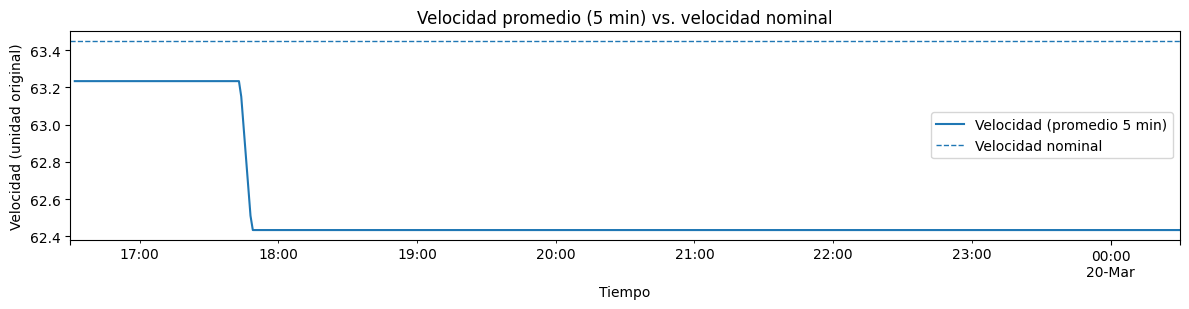


=== Indicadores por DÍA ===


/tmp/ipython-input-2084742588.py:147: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  por_dia = out.groupby("fecha").apply(agg_period).reset_index()


,fecha,disponibilidad,rendimiento,calidad,min_PARO,min_PRODUCCION,min_DESPERDICIO,min_SETUP,min_total
0,2024-03-19,1.0,0.986073,0.337838,0.0,125.0,245.0,80.0,450.0
1,2024-03-20,1.0,0.980358,0.680556,0.0,980.0,460.0,0.0,1440.0
2,2024-03-21,1.0,0.975834,0.504861,0.0,727.0,713.0,0.0,1440.0
3,2024-03-22,1.0,0.976635,0.291289,0.0,321.0,781.0,338.0,1440.0
4,2024-03-23,1.0,0.977689,0.626168,0.0,737.0,440.0,263.0,1440.0



=== Indicadores por DÍA y TURNO ===


/tmp/ipython-input-2084742588.py:153: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  por_dia_turno = out.groupby(["fecha", "turno"]).apply(agg_period).reset_index()


,fecha,turno,disponibilidad,rendimiento,calidad,min_PARO,min_PRODUCCION,min_DESPERDICIO,min_SETUP,min_total
0,2024-03-19,Turno B (14-22),1.0,0.986840,0.304000,0.0,76.0,174.0,80.0,330.0
1,2024-03-19,Turno C (22-06),1.0,0.983977,0.408333,0.0,49.0,71.0,0.0,120.0
2,2024-03-20,Turno A (06-14),1.0,0.983298,0.797917,0.0,383.0,97.0,0.0,480.0
3,2024-03-20,Turno B (14-22),1.0,0.975834,0.741667,0.0,356.0,124.0,0.0,480.0
4,2024-03-20,Turno C (22-06),1.0,0.981941,0.502083,0.0,241.0,239.0,0.0,480.0


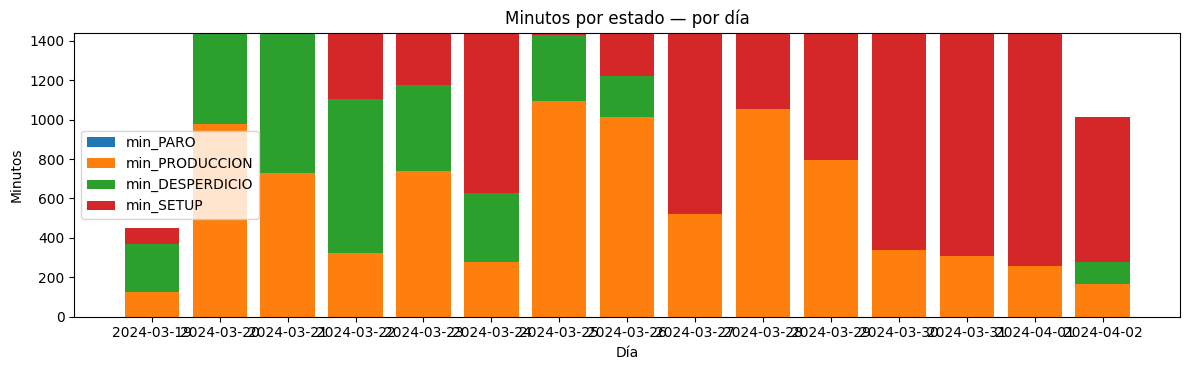

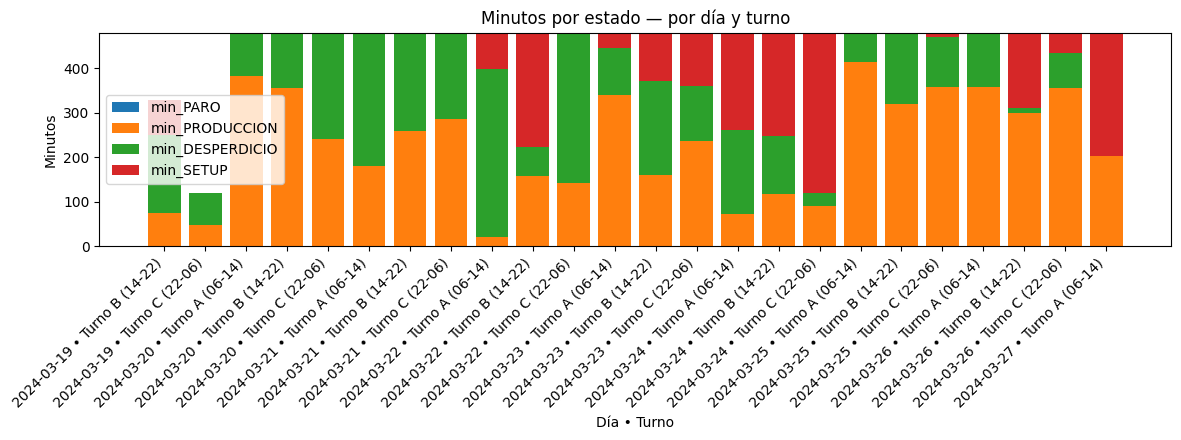

<Figure size 1200x320 with 0 Axes>

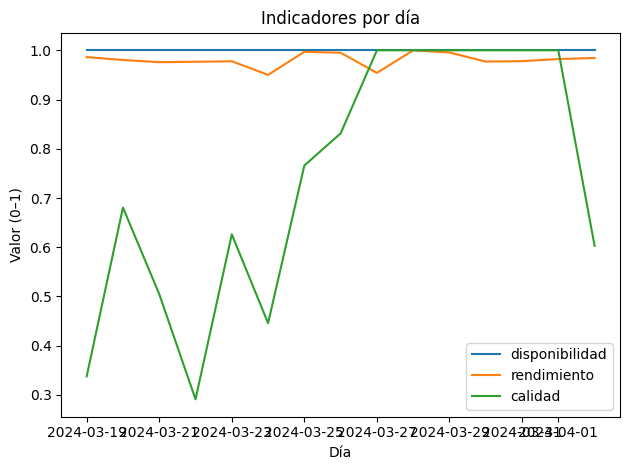

<Figure size 1200x350 with 0 Axes>

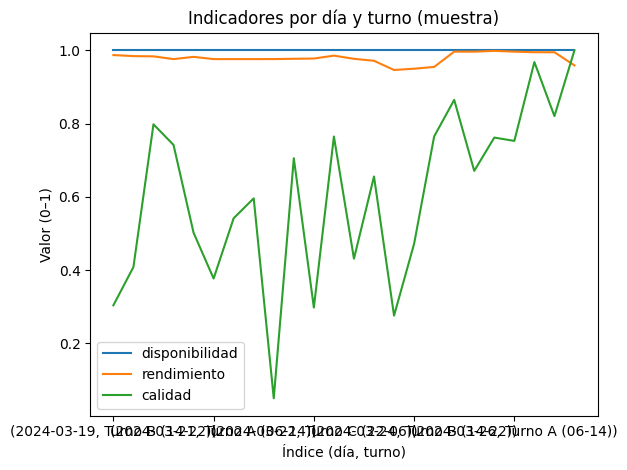


=== Índice combinado (día) ===


,fecha,disponibilidad,rendimiento,calidad,indice_combinado
0,2024-03-19,1.0,0.986073,0.337838,0.333133
1,2024-03-20,1.0,0.980358,0.680556,0.667188
2,2024-03-21,1.0,0.975834,0.504861,0.492661
3,2024-03-22,1.0,0.976635,0.291289,0.284483
4,2024-03-23,1.0,0.977689,0.626168,0.612198



=== Índice combinado (día y turno) ===


,fecha,turno,disponibilidad,rendimiento,calidad,indice_combinado
0,2024-03-19,Turno B (14-22),1.0,0.986840,0.304000,0.299999
1,2024-03-19,Turno C (22-06),1.0,0.983977,0.408333,0.401791
2,2024-03-20,Turno A (06-14),1.0,0.983298,0.797917,0.784590
3,2024-03-20,Turno B (14-22),1.0,0.975834,0.741667,0.723744
4,2024-03-20,Turno C (22-06),1.0,0.981941,0.502083,0.493016


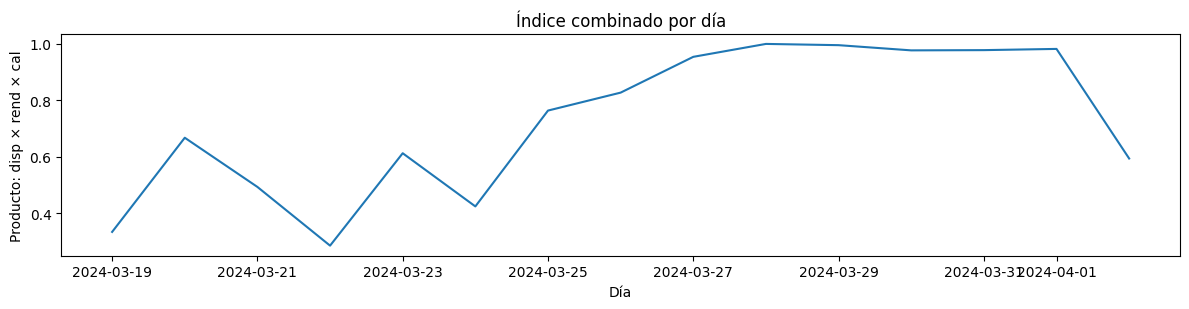


✅ BLOQUE 3 completado.


In [12]:
# =========================================
# Requisitos previos: timeline (con columna 'estado'), features, df_1min, TS_COL, familias_1min
# =========================================
from IPython.display import display

# ---------- 0) Validaciones ----------
need = ["timeline", "features", "df_1min", "TS_COL", "familias_1min"]
for n in need:
    if n not in globals():
        raise RuntimeError(f"Falta '{n}' en el entorno. Ejecuta Bloques 1–2 primero.")

assert "estado" in timeline.columns, "El DataFrame 'timeline' debe tener la columna 'estado'."

# ---------- 1) Recordatorio corto: ¿qué es una ventana? ----------
# Una ventana es un intervalo que “se desliza” a lo largo del tiempo.
# Aquí usamos ventanas de 5 minutos (paso de 1 minuto) para calcular promedios y variaciones
# recientes de variables clave (velocidad de haladores, RPM, presión, desviación de cabezal).
# Objetivo: reducir ruido y representar el "comportamiento reciente" de cada minuto.

# Estas columnas vienen del Bloque 2B:
# - hal_speed_mean_5m: velocidad promedio de haladores en los últimos 5 minutos.
# - hal_speed_std_5m : variación de esa velocidad en 5 minutos.
# - rpm_level_mean_5m, rpm_var_t_5m: nivel y variación de RPM en 5 minutos (si exite RPM).
# - pres_level_mean_5m: nivel de presión en 5 minutos (si existe presión).
# - cbz_dev_mean_5m: desviación |VP-SP| promedio de cabezal en 5 minutos (si existe).

# ---------- 2) Selección de columnas que usaremos para el cálculo ----------
must_cols = ["hal_speed_mean_5m", "hal_speed_std_5m"]
for c in must_cols:
    if c not in timeline.columns:
        raise RuntimeError(f"No se encontró '{c}' en timeline. Asegúrate de haber corrido el Bloque 2B completo.")

# ---------- 3) Cálculo de la VELOCIDAD NOMINAL (necesaria para Rendimiento) ----------
# Idea simple: tomar la velocidad típica "alta y estable" cuando el estado es PRODUCCION.
# - Filtramos los minutos etiquetados como PRODUCCION.
# - De esos, nos quedamos con velocidad estable (variación baja, por debajo del cuartil 25 de su std).
# - Sobre esas muestras, tomamos el cuantil 90 de la velocidad promedio → "velocidad nominal".
prod_mask = timeline["estado"].eq("PRODUCCION")
stable_mask = timeline["hal_speed_std_5m"].notna()
if stable_mask.any():
    # umbral de variación baja (p25 de la std durante PRODUCCION)
    var_p25 = timeline.loc[prod_mask & stable_mask, "hal_speed_std_5m"].quantile(0.25)
else:
    var_p25 = np.nan

if np.isnan(var_p25):
    # Si no hay suficientes datos en PRODUCCION, usamos todo el historial como fallback
    base_for_nominal = timeline["hal_speed_mean_5m"].dropna()
else:
    base_for_nominal = timeline.loc[
        prod_mask & (timeline["hal_speed_std_5m"] <= var_p25),
        "hal_speed_mean_5m"
    ].dropna()

if len(base_for_nominal) == 0:
    # Último recurso: usa el p90 de todas las velocidades positivas
    base_for_nominal = timeline.loc[timeline["hal_speed_mean_5m"] > 0, "hal_speed_mean_5m"].dropna()

if len(base_for_nominal) == 0:
    raise RuntimeError("No hay datos de velocidad para estimar un valor nominal.")

velocidad_nominal = float(base_for_nominal.quantile(0.90))
# Evita división por cero
if velocidad_nominal <= 0:
    # como red de seguridad, toma la media de las positivas
    positives = timeline.loc[timeline["hal_speed_mean_5m"] > 0, "hal_speed_mean_5m"]
    velocidad_nominal = float(max(positives.mean(), 1e-6))

print("=== Velocidad nominal (estimada desde tus datos) ===")
print(velocidad_nominal)

# ---------- 4) Métricas por minuto (Disponibilidad, Rendimiento, Calidad) ----------
out = timeline.copy()

# Disponibilidad: 1 si el estado no es PARO; 0 si es PARO.
out["disp_min"] = (~out["estado"].eq("PARO")).astype("float64")

# Rendimiento: velocidad promedio (5 min) / velocidad nominal, capado a [0,1]
# Nota: si hal_speed_mean_5m es NaN (por ventanas al inicio), resultará NaN y se ignorará en agregaciones.
out["rend_min"] = (out["hal_speed_mean_5m"] / velocidad_nominal).clip(lower=0, upper=1)

# Calidad (aprox. sin datos manuales):
# - Solo cuenta cuando la línea está activa (PRODUCCION o DESPERDICIO).
# - "Bueno" si el estado es PRODUCCION; "No bueno" si es DESPERDICIO.
out["activo_min"] = out["estado"].isin(["PRODUCCION", "DESPERDICIO"]).astype("float64")
out["calidad_bueno_min"] = (out["estado"].eq("PRODUCCION")).astype("float64")
# La calidad por periodo será: sum(calidad_bueno_min) / sum(activo_min)

# ---------- 5) Salidas intermedias (tabla corta) ----------
print("\n=== Muestra (10 filas) de métricas por minuto ===")
display(out[["estado", "hal_speed_mean_5m", "hal_speed_std_5m", "disp_min", "rend_min", "activo_min", "calidad_bueno_min"]].head(10))

# ---------- 6) Gráficas intermedias: velocidad vs. nominal (tramo corto) ----------
# Para no saturar, graficamos ~8 horas desde el inicio. Ajusta PLOT_HOURS si quieres.
PLOT_HOURS = 8
start_ts = out.index.min()
end_ts = min(out.index.max(), start_ts + pd.Timedelta(hours=PLOT_HOURS))
plot_slice = slice(start_ts, end_ts)

plt.figure(figsize=(12, 3.2))
out.loc[plot_slice, "hal_speed_mean_5m"].plot(label="Velocidad (promedio 5 min)")
plt.axhline(velocidad_nominal, linestyle="--", linewidth=1.0, label="Velocidad nominal")
plt.title("Velocidad promedio (5 min) vs. velocidad nominal")
plt.xlabel("Tiempo"); plt.ylabel("Velocidad (unidad original)")
plt.legend(); plt.tight_layout(); plt.show()

# ---------- 7) Agregaciones por DÍA y por TURNO ----------
# Definimos 3 turnos de 8 horas:
# - Turno A: 06:00–13:59
# - Turno B: 14:00–21:59
# - Turno C: 22:00–05:59 (cruza medianoche)
def asignar_turno(ts):
    h = ts.hour
    if 6 <= h < 14:
        return "Turno A (06-14)"
    elif 14 <= h < 22:
        return "Turno B (14-22)"
    else:
        return "Turno C (22-06)"

out["fecha"] = out.index.date
out["turno"] = [asignar_turno(ts) for ts in out.index]

# Agregación por día: promedio de cada indicador + cuenta de minutos por estado
def agg_period(dfp):
    # promedios (ignorando NaN)
    disp = dfp["disp_min"].mean()
    # rendimiento medio ponderado por minutos válidos
    rend = dfp["rend_min"].mean()
    # calidad: buenos / activos (si no hay activos, NaN)
    activos = dfp["activo_min"].sum()
    buenos  = dfp["calidad_bueno_min"].sum()
    calidad = np.nan if activos == 0 else (buenos / activos)
    # estados (conteo de minutos)
    estados_count = dfp["estado"].value_counts()
    return pd.Series({
        "disponibilidad": disp,
        "rendimiento": rend,
        "calidad": calidad,
        "min_PARO": int(estados_count.get("PARO", 0)),
        "min_PRODUCCION": int(estados_count.get("PRODUCCION", 0)),
        "min_DESPERDICIO": int(estados_count.get("DESPERDICIO", 0)),
        "min_SETUP": int(estados_count.get("SETUP", 0)),
        "min_total": int(len(dfp))
    })

por_dia = out.groupby("fecha").apply(agg_period).reset_index()

print("\n=== Indicadores por DÍA ===")
display(por_dia.head())

# Agregación por día+turno
por_dia_turno = out.groupby(["fecha", "turno"]).apply(agg_period).reset_index()
print("\n=== Indicadores por DÍA y TURNO ===")
display(por_dia_turno.head())

# ---------- 8) Gráficas: minutos por estado (barras apiladas) ----------
# (a) Por día
est_cols = ["min_PARO", "min_PRODUCCION", "min_DESPERDICIO", "min_SETUP"]
plt.figure(figsize=(12, 3.8))
# convertimos fecha a string para un eje x legible
xlabels = por_dia["fecha"].astype(str)
bottom = np.zeros(len(por_dia))
for col in est_cols:
    plt.bar(xlabels, por_dia[col], bottom=bottom, label=col)
    bottom = bottom + por_dia[col].to_numpy()
plt.title("Minutos por estado — por día")
plt.xlabel("Día"); plt.ylabel("Minutos")
plt.legend(); plt.tight_layout(); plt.show()

# (b) Por día y turno (usa las primeras N filas para no saturar si hay muchos días)
N = min(24, len(por_dia_turno))  # ajusta si quieres ver más
subset = por_dia_turno.iloc[:N].copy()
xlabels2 = subset["fecha"].astype(str) + " • " + subset["turno"]
plt.figure(figsize=(12, 4.5))
bottom = np.zeros(len(subset))
for col in est_cols:
    plt.bar(xlabels2, subset[col], bottom=bottom, label=col)
    bottom = bottom + subset[col].to_numpy()
plt.title("Minutos por estado — por día y turno")
plt.xlabel("Día • Turno"); plt.ylabel("Minutos")
plt.xticks(rotation=45, ha="right")
plt.legend(); plt.tight_layout(); plt.show()

# ---------- 9) Gráficas: indicadores (disponibilidad, rendimiento, calidad) ----------
# (a) Por día
plt.figure(figsize=(12, 3.2))
por_dia.set_index("fecha")[["disponibilidad", "rendimiento", "calidad"]].plot()
plt.title("Indicadores por día")
plt.xlabel("Día"); plt.ylabel("Valor (0–1)")
plt.tight_layout(); plt.show()

# (b) Por día y turno (muestra N primeros para legibilidad)
plt.figure(figsize=(12, 3.5))
subset_idx = por_dia_turno.set_index(["fecha", "turno"])[["disponibilidad", "rendimiento", "calidad"]].head(24)
subset_idx.plot()
plt.title("Indicadores por día y turno (muestra)")
plt.xlabel("Índice (día, turno)"); plt.ylabel("Valor (0–1)")
plt.tight_layout(); plt.show()

# ---------- 10) Índice combinado (producto simple) ----------
# Aunque no lo nombraremos con siglas, es útil ver el producto de: disponibilidad × rendimiento × calidad.
por_dia["indice_combinado"] = por_dia["disponibilidad"] * por_dia["rendimiento"] * por_dia["calidad"]
por_dia_turno["indice_combinado"] = por_dia_turno["disponibilidad"] * por_dia_turno["rendimiento"] * por_dia_turno["calidad"]

print("\n=== Índice combinado (día) ===")
display(por_dia[["fecha", "disponibilidad", "rendimiento", "calidad", "indice_combinado"]].head())

print("\n=== Índice combinado (día y turno) ===")
display(por_dia_turno[["fecha", "turno", "disponibilidad", "rendimiento", "calidad", "indice_combinado"]].head())

plt.figure(figsize=(12, 3.2))
por_dia.set_index("fecha")["indice_combinado"].plot()
plt.title("Índice combinado por día")
plt.xlabel("Día"); plt.ylabel("Producto: disp × rend × cal")
plt.tight_layout(); plt.show()

# ---------- 11) (Opcional) Exportar artefactos para el repositorio ----------
# por_dia.to_csv("indicadores_por_dia.csv", index=False)
# por_dia_turno.to_csv("indicadores_por_dia_turno.csv", index=False)

print("\n✅ BLOQUE 3 completado.")
